# Preprocessing — COVID-19 Validation Set (20 scans)
**Source** : `Yousra0x0/validation_20`  
**Format** : NIfTI (`.nii.gz`) — CT + masques multi-labels (1=poumon gauche, 2=poumon droit, 3=infection)  
**Pipeline** : identique LUNA16 — HU clip `[-1000, 200]` → minmax `[0,1]` → sélection slices → resize `128³` → `.h5`  
**Masque** : on binarise **labels 1 & 2 uniquement** (poumons), on ignore le label 3 (infection)


In [ ]:
!pip install -q huggingface_hub SimpleITK nibabel h5py scipy scikit-image tqdm

import importlib
for pkg in ["SimpleITK", "nibabel", "h5py", "numpy", "scipy", "skimage", "tqdm", "huggingface_hub"]:
    try:
        importlib.import_module(pkg if pkg != "skimage" else "skimage")
        print(f"  OK : {pkg}")
    except ImportError:
        print(f"  MISSING : {pkg}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 10.8 MB/s eta 0:00:00
  OK : SimpleITK
  OK : nibabel
  OK : h5py
  OK : numpy
  OK : scipy
  OK : skimage
  OK : tqdm
  OK : huggingface_hub


In [ ]:
from google.colab import userdata
from huggingface_hub import login

# Récupérer le token depuis Colab (stocké de façon sécurisée)
HF_TOKEN = userdata.get('HF_TOKEN')

# Vérifier que le token existe
if HF_TOKEN is None:
    raise ValueError("HF_TOKEN not found in Colab secrets")

# Connexion à Hugging Face
login(token=HF_TOKEN)


In [ ]:
import os, torch

# ── Repos HuggingFace ────────────────────────────────────────────────────────
REPO_RAW    = "Yousra0x0/validation_20"          # data brute (NIfTI)
REPO_H5_OUT = "Yousra0x0/validation_20_preprocessed"  # sortie .h5

# ── Répertoires Colab (temporaires) ─────────────────────────────────────────
DIR_RAW = "/content/val20_raw"
DIR_H5  = "/content/val20_h5"

os.makedirs(DIR_RAW, exist_ok=True)
os.makedirs(DIR_H5,  exist_ok=True)

# ── Paramètres de preprocessing (identiques LUNA16) ─────────────────────────
HU_MIN          = -1000
HU_MAX          = 200
TARGET_SHAPE    = (128, 128, 128)   # (Z, Y, X) après resize
MIN_SLICES      = 10                # minimum de slices valides (réduit : 20 scans seulement)
MAX_SLICES      = 120
MAX_EMPTY_RATIO = 0.20              # tolérance plus haute (certains scans COVID ont + de slices vides)
EMPTY_THRESH    = 1e-5              # un slice est "vide" si son max < ce seuil (après normalisation)

# ── Labels masque ────────────────────────────────────────────────────────────
# 1 = poumon gauche, 2 = poumon droit, 3 = infection
# On garde UNIQUEMENT les poumons pour rester cohérent avec LUNA16
LUNG_LABELS = [1, 2]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device      : {DEVICE}")
print(f"REPO_RAW    : {REPO_RAW}")
print(f"REPO_H5_OUT : {REPO_H5_OUT}")
print(f"HU clip     : [{HU_MIN}, {HU_MAX}]")
print(f"Target shape: {TARGET_SHAPE}")
print(f"Lung labels : {LUNG_LABELS}")


Device      : cpu
REPO_RAW    : Yousra0x0/validation_20
REPO_H5_OUT : Yousra0x0/validation_20_preprocessed
HU clip     : [-1000, 200]
Target shape: (128, 128, 128)
Lung labels : [1, 2]


In [ ]:
from huggingface_hub import list_repo_files
from pathlib import Path
from collections import defaultdict

print(f"Listing {REPO_RAW} ...")
all_files = list(list_repo_files(repo_id=REPO_RAW, repo_type="dataset", token=HF_TOKEN))
print(f"  {len(all_files)} fichiers trouvés")

# Grouper par extension et dossier
by_folder = defaultdict(list)
for f in sorted(all_files):
    folder = str(Path(f).parent)
    by_folder[folder].append(f)

for folder, files in sorted(by_folder.items()):
    print(f"\n  [{folder}]  ({len(files)} fichiers)")
    for f in files[:8]:
        print(f"    {f}")
    if len(files) > 8:
        print(f"    ... (+{len(files)-8} autres)")


Listing Yousra0x0/validation_20 ...
  42 fichiers trouvés

  [.]  (2 fichiers)
    .gitattributes
    ReadMe.txt

  [images]  (20 fichiers)
    images/coronacases_001.nii.gz
    images/coronacases_002.nii.gz
    images/coronacases_003.nii.gz
    images/coronacases_004.nii.gz
    images/coronacases_005.nii.gz
    images/coronacases_006.nii.gz
    images/coronacases_007.nii.gz
    images/coronacases_008.nii.gz
    ... (+12 autres)

  [masks]  (20 fichiers)
    masks/coronacases_001.nii.gz
    masks/coronacases_002.nii.gz
    masks/coronacases_003.nii.gz
    masks/coronacases_004.nii.gz
    masks/coronacases_005.nii.gz
    masks/coronacases_006.nii.gz
    masks/coronacases_007.nii.gz
    masks/coronacases_008.nii.gz
    ... (+12 autres)


In [ ]:
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# Adapter ce bloc APRÈS avoir exécuté la cellule d'exploration (Cell 5)
# On cherche les fichiers .nii.gz dans le repo
# ─────────────────────────────────────────────────────────────────────────────

nii_files = [f for f in all_files if f.endswith(".nii.gz") or f.endswith(".nii")]
print(f"Fichiers NIfTI trouvés : {len(nii_files)}")
for f in nii_files[:20]:
    print(f"  {f}")

# ─────────────────────────────────────────────────────────────────────────────
# Heuristique de séparation CT / masques
# On détecte les masques par mots-clés dans le chemin
# ─────────────────────────────────────────────────────────────────────────────

MASK_KEYWORDS = ["mask", "seg", "label", "annotation", "gt", "ground"]

def is_mask_file(path_str):
    p = path_str.lower()
    return any(kw in p for kw in MASK_KEYWORDS)

ct_files   = [f for f in nii_files if not is_mask_file(f)]
mask_files = [f for f in nii_files if is_mask_file(f)]

print(f"\nCT scans  : {len(ct_files)}")
for f in ct_files: print(f"  {f}")

print(f"\nMasques   : {len(mask_files)}")
for f in mask_files: print(f"  {f}")

# ─────────────────────────────────────────────────────────────────────────────
# Si la séparation automatique est incorrecte, tu peux la corriger manuellement
# en redéfinissant ct_files et mask_files ici
# ─────────────────────────────────────────────────────────────────────────────
# Exemple :
# ct_files   = [f for f in nii_files if "ct_scan" in f]
# mask_files = [f for f in nii_files if "lung_mask" in f]


Fichiers NIfTI trouvés : 40
  images/coronacases_001.nii.gz
  images/coronacases_002.nii.gz
  images/coronacases_003.nii.gz
  images/coronacases_004.nii.gz
  images/coronacases_005.nii.gz
  images/coronacases_006.nii.gz
  images/coronacases_007.nii.gz
  images/coronacases_008.nii.gz
  images/coronacases_009.nii.gz
  images/coronacases_010.nii.gz
  images/radiopaedia_10_85902_1.nii.gz
  images/radiopaedia_10_85902_3.nii.gz
  images/radiopaedia_14_85914_0.nii.gz
  images/radiopaedia_27_86410_0.nii.gz
  images/radiopaedia_29_86490_1.nii.gz
  images/radiopaedia_29_86491_1.nii.gz
  images/radiopaedia_36_86526_0.nii.gz
  images/radiopaedia_40_86625_0.nii.gz
  images/radiopaedia_4_85506_1.nii.gz
  images/radiopaedia_7_85703_0.nii.gz

CT scans  : 20
  images/coronacases_001.nii.gz
  images/coronacases_002.nii.gz
  images/coronacases_003.nii.gz
  images/coronacases_004.nii.gz
  images/coronacases_005.nii.gz
  images/coronacases_006.nii.gz
  images/coronacases_007.nii.gz
  images/coronacases_008

In [ ]:
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# Appairage automatique par stem (nom de fichier sans extension)
# ex: "ct_scans/coronacases_001.nii.gz" ↔ "lung_mask/coronacases_001.nii.gz"
# ─────────────────────────────────────────────────────────────────────────────

def get_stem(path_str):
    """Retourne le nom de fichier sans toutes les extensions (.nii.gz, .nii, etc.)"""
    p = Path(path_str)
    name = p.name
    for ext in [".nii.gz", ".nii"]:
        if name.endswith(ext):
            name = name[:-len(ext)]
            break
    return name

ct_by_stem   = {get_stem(f): f for f in ct_files}
mask_by_stem = {get_stem(f): f for f in mask_files}

# Intersection
paired_stems = sorted(set(ct_by_stem.keys()) & set(mask_by_stem.keys()))
ct_only      = sorted(set(ct_by_stem.keys()) - set(mask_by_stem.keys()))
mask_only    = sorted(set(mask_by_stem.keys()) - set(ct_by_stem.keys()))

print(f"Paires CT+masque trouvées : {len(paired_stems)}")
print(f"CT sans masque            : {len(ct_only)}  → {ct_only}")
print(f"Masques sans CT           : {len(mask_only)} → {mask_only}")

if not paired_stems:
    print("\n⚠️  Aucune paire automatique — vérifier la structure du repo")
    print("   Ajuste la cellule 6 (MASK_KEYWORDS ou filtres manuels)")
else:
    print("\nPremières paires :")
    for stem in paired_stems[:5]:
        print(f"  {stem}")
        print(f"    CT   : {ct_by_stem[stem]}")
        print(f"    Mask : {mask_by_stem[stem]}")


Paires CT+masque trouvées : 20
CT sans masque            : 0  → []
Masques sans CT           : 0 → []

Premières paires :
  coronacases_001
    CT   : images/coronacases_001.nii.gz
    Mask : masks/coronacases_001.nii.gz
  coronacases_002
    CT   : images/coronacases_002.nii.gz
    Mask : masks/coronacases_002.nii.gz
  coronacases_003
    CT   : images/coronacases_003.nii.gz
    Mask : masks/coronacases_003.nii.gz
  coronacases_004
    CT   : images/coronacases_004.nii.gz
    Mask : masks/coronacases_004.nii.gz
  coronacases_005
    CT   : images/coronacases_005.nii.gz
    Mask : masks/coronacases_005.nii.gz


In [ ]:
import numpy as np
import SimpleITK as sitk
import nibabel as nib
from scipy.ndimage import zoom
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# Chargement NIfTI — deux backends au choix
# On essaie SimpleITK d'abord (cohérent LUNA16), fallback nibabel
# ─────────────────────────────────────────────────────────────────────────────

def load_nifti_sitk(path):
    """Charge un .nii/.nii.gz → numpy (Z, Y, X) float32 via SimpleITK."""
    img = sitk.ReadImage(str(path))
    return sitk.GetArrayFromImage(img).astype(np.float32)

def load_nifti_nib(path):
    """Charge un .nii/.nii.gz → numpy (Z, Y, X) float32 via nibabel.
    nibabel retourne (X, Y, Z) → on transpose.
    """
    nii = nib.load(str(path))
    arr = nii.get_fdata(dtype=np.float32)        # (X, Y, Z)
    return arr.transpose(2, 1, 0)                 # → (Z, Y, X)

def load_volume(path):
    """Chargement avec fallback nibabel si SimpleITK échoue."""
    try:
        return load_nifti_sitk(path)
    except Exception as e_sitk:
        try:
            return load_nifti_nib(path)
        except Exception as e_nib:
            raise RuntimeError(f"Impossible de lire {path}\n  sitk: {e_sitk}\n  nib: {e_nib}")

# ─────────────────────────────────────────────────────────────────────────────
# Pipeline identique LUNA16
# ─────────────────────────────────────────────────────────────────────────────

def hu_clip(volume):
    """Clamp HU values to [HU_MIN, HU_MAX]."""
    return np.clip(volume, HU_MIN, HU_MAX)

def minmax_normalize(volume):
    """Normalize to [0, 1]."""
    v_min, v_max = volume.min(), volume.max()
    if v_max - v_min < 1e-8:
        return np.zeros_like(volume)
    return (volume - v_min) / (v_max - v_min)

def binarize_lung_mask(mask_arr):
    """
    Convertit le masque multi-label en masque binaire de poumon.
    Labels : 1=poumon gauche, 2=poumon droit, 3=infection (ignoré)
    """
    binary = np.zeros_like(mask_arr, dtype=np.float32)
    for lbl in LUNG_LABELS:
        binary[mask_arr == lbl] = 1.0
    return binary

def select_valid_slices(volume, mask):
    """
    Filtre les slices vides.
    Retourne (None, None) si le volume est rejeté.
    """
    n = volume.shape[0]
    empty_flags = np.array([volume[i].max() < EMPTY_THRESH for i in range(n)])
    if empty_flags.sum() / n > MAX_EMPTY_RATIO:
        return None, None   # trop de slices vides → rejeté
    valid_idx = np.where(~empty_flags)[0]
    if len(valid_idx) < MIN_SLICES:
        return None, None   # pas assez de slices valides
    if len(valid_idx) > MAX_SLICES:
        c    = len(valid_idx) // 2
        half = MAX_SLICES // 2
        valid_idx = valid_idx[c - half : c + half]
    return volume[valid_idx], mask[valid_idx]

def resize_volume(volume, target=TARGET_SHAPE):
    """Resize (Z,Y,X) → TARGET_SHAPE avec interpolation linéaire."""
    factors = [t / s for t, s in zip(target, volume.shape)]
    return zoom(volume, factors, order=1).astype(np.float32)

print("Fonctions de preprocessing définies :")
print("  load_volume()        — NIfTI (.nii/.nii.gz), fallback nibabel")
print("  hu_clip()            — clamp HU [-1000, 200]")
print("  minmax_normalize()   — normalisation [0, 1]")
print("  binarize_lung_mask() — labels 1+2 → binaire, ignore label 3 (infection)")
print("  select_valid_slices()— filtre slices vides")
print("  resize_volume()      — zoom scipy → 128³")


Fonctions de preprocessing définies :
  load_volume()        — NIfTI (.nii/.nii.gz), fallback nibabel
  hu_clip()            — clamp HU [-1000, 200]
  minmax_normalize()   — normalisation [0, 1]
  binarize_lung_mask() — labels 1+2 → binaire, ignore label 3 (infection)
  select_valid_slices()— filtre slices vides
  resize_volume()      — zoom scipy → 128³


In [ ]:
import h5py
from huggingface_hub import hf_hub_download

# ─────────────────────────────────────────────────────────────────────────────
# Test du pipeline sur le PREMIER cas avant de tout lancer
# ─────────────────────────────────────────────────────────────────────────────

test_stem = paired_stems[0]
print(f"Test sur : {test_stem}")

# Télécharger CT
ct_hf_path   = ct_by_stem[test_stem]
mask_hf_path = mask_by_stem[test_stem]

ct_local   = hf_hub_download(repo_id=REPO_RAW, filename=ct_hf_path,
                               repo_type="dataset", token=HF_TOKEN, local_dir=DIR_RAW)
mask_local = hf_hub_download(repo_id=REPO_RAW, filename=mask_hf_path,
                               repo_type="dataset", token=HF_TOKEN, local_dir=DIR_RAW)

print(f"  CT   : {ct_local}")
print(f"  Mask : {mask_local}")

# Charger
ct_raw   = load_volume(ct_local)
mask_raw = load_volume(mask_local)
print(f"\n  CT brut   : shape={ct_raw.shape}  min={ct_raw.min():.0f}  max={ct_raw.max():.0f}  dtype={ct_raw.dtype}")
print(f"  Mask brut : shape={mask_raw.shape}  labels uniques={np.unique(mask_raw).tolist()}")

# Vérifier les HU — les CT NIfTI de ce dataset stockent les HU directement
# Si le min est proche de -1000 → HU natifs, pipeline LUNA16 applicable directement
print(f"\n  Vérification HU : min={ct_raw.min():.0f}, max={ct_raw.max():.0f}")
if ct_raw.min() < -500:
    print("  → HU natifs détectés ✓")
else:
    print("  ⚠️  Min > -500 — peut-être déjà normalisé ou pas en HU !")
    print("  → Vérifie si le clip HU est adapté avant de lancer le preprocessing complet")

# Pipeline
ct_clipped  = hu_clip(ct_raw)
ct_norm     = minmax_normalize(ct_clipped)
mask_binary = binarize_lung_mask(mask_raw)

print(f"\n  Après clip+norm : min={ct_norm.min():.3f}  max={ct_norm.max():.3f}")
print(f"  Masque binaire  : lung pixels = {int(mask_binary.sum())}  "
      f"({100*mask_binary.mean():.1f}% du volume)")

ct_sliced, mask_sliced = select_valid_slices(ct_norm, mask_binary)
if ct_sliced is None:
    print("  ⚠️  Volume REJETÉ par select_valid_slices — ajuste MIN_SLICES/MAX_EMPTY_RATIO")
else:
    print(f"  Après sélection slices : {ct_sliced.shape[0]} slices sélectionnées")
    ct_resized   = resize_volume(ct_sliced)
    mask_resized = resize_volume(mask_sliced)
    mask_resized = (mask_resized > 0.5).astype(np.float32)
    print(f"  Après resize : CT={ct_resized.shape}  Mask={mask_resized.shape}")
    print(f"  Mask final   : lung pixels = {int(mask_resized.sum())}")
    print(f"\n  Test OK ✓ — pipeline fonctionnel sur {test_stem}")


Test sur : coronacases_001


images/coronacases_001.nii.gz:   0%|          | 0.00/93.2M [00:00<?, ?B/s]

masks/coronacases_001.nii.gz:   0%|          | 0.00/1.19M [00:00<?, ?B/s]

  CT   : /content/val20_raw/images/coronacases_001.nii.gz
  Mask : /content/val20_raw/masks/coronacases_001.nii.gz

  CT brut   : shape=(301, 512, 512)  min=-1021  max=2996  dtype=float32
  Mask brut : shape=(301, 512, 512)  labels uniques=[0.0, 1.0, 2.0]

  Vérification HU : min=-1021, max=2996
  → HU natifs détectés ✓

  Après clip+norm : min=0.000  max=1.000
  Masque binaire  : lung pixels = 5052909  (6.4% du volume)
  Après sélection slices : 120 slices sélectionnées
  Après resize : CT=(128, 128, 128)  Mask=(128, 128, 128)
  Mask final   : lung pixels = 255924

  Test OK ✓ — pipeline fonctionnel sur coronacases_001


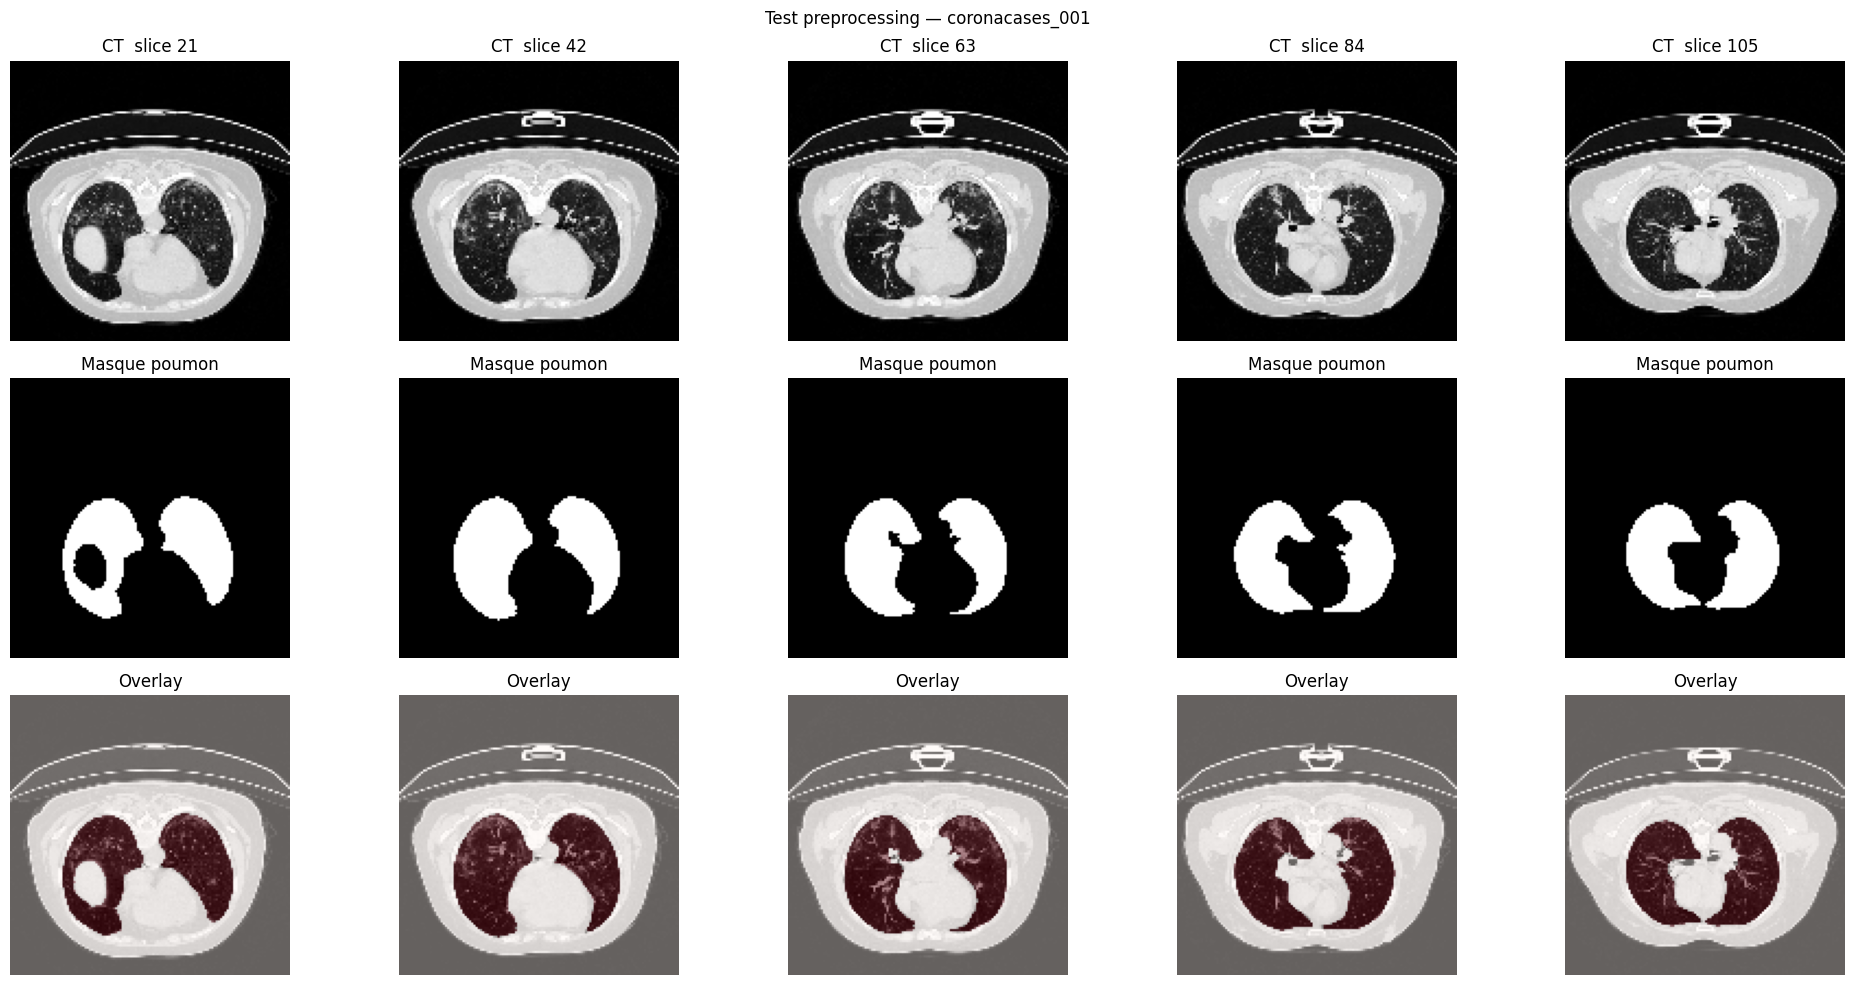

In [ ]:
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation : 5 slices du volume testé (CT | Masque binaire | Overlay)
# ─────────────────────────────────────────────────────────────────────────────

n_slices_visu = 5
step = ct_resized.shape[0] // (n_slices_visu + 1)
slice_indices = [step * (i + 1) for i in range(n_slices_visu)]

fig, axes = plt.subplots(3, n_slices_visu, figsize=(4 * n_slices_visu, 10))
fig.suptitle(f"Test preprocessing — {test_stem}", fontsize=12)

for col, idx in enumerate(slice_indices):
    ct_sl   = ct_resized[idx]
    mask_sl = mask_resized[idx]

    # CT
    axes[0, col].imshow(ct_sl, cmap="gray")
    axes[0, col].set_title(f"CT  slice {idx}")
    axes[0, col].axis("off")

    # Masque
    axes[1, col].imshow(mask_sl, cmap="gray")
    axes[1, col].set_title("Masque poumon")
    axes[1, col].axis("off")

    # Overlay
    axes[2, col].imshow(ct_sl, cmap="gray")
    axes[2, col].imshow(mask_sl, cmap="Reds", alpha=0.4)
    axes[2, col].set_title("Overlay")
    axes[2, col].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import json, os, shutil
from pathlib import Path
from tqdm.notebook import tqdm
from huggingface_hub import HfApi, hf_hub_download, list_repo_files
import h5py

api = HfApi(token=HF_TOKEN)

# ─────────────────────────────────────────────────────────────────────────────
# Créer le repo de sortie
# ─────────────────────────────────────────────────────────────────────────────
api.create_repo(repo_id=REPO_H5_OUT, repo_type="dataset", exist_ok=True)
print(f"Repo prêt : https://huggingface.co/datasets/{REPO_H5_OUT}")

# ─────────────────────────────────────────────────────────────────────────────
# Identifier les cas déjà traités (resume)
# ─────────────────────────────────────────────────────────────────────────────
try:
    done_files = list(list_repo_files(repo_id=REPO_H5_OUT, repo_type="dataset", token=HF_TOKEN))
    done_stems = {Path(f).stem for f in done_files if f.endswith(".h5")}
    print(f"Déjà preprocessés : {len(done_stems)} cas")
except Exception:
    done_stems = set()
    print("Repo vide, démarrage from scratch.")

# ─────────────────────────────────────────────────────────────────────────────
# Loop principale
# ─────────────────────────────────────────────────────────────────────────────
results_log = {}   # stem → "ok" | "rejected" | "error:..."

to_process = [s for s in paired_stems if s not in done_stems]
print(f"\nCas à traiter : {len(to_process)} / {len(paired_stems)}")

for stem in tqdm(to_process, desc="Preprocessing"):
    ct_hf_path   = ct_by_stem[stem]
    mask_hf_path = mask_by_stem[stem]

    try:
        # 1. Télécharger
        ct_local = hf_hub_download(
            repo_id=REPO_RAW, filename=ct_hf_path,
            repo_type="dataset", token=HF_TOKEN, local_dir=DIR_RAW
        )
        mask_local = hf_hub_download(
            repo_id=REPO_RAW, filename=mask_hf_path,
            repo_type="dataset", token=HF_TOKEN, local_dir=DIR_RAW
        )

        # 2. Charger
        ct_raw   = load_volume(ct_local)
        mask_raw = load_volume(mask_local)

        # 3. Preprocessing
        ct_processed   = minmax_normalize(hu_clip(ct_raw))
        mask_processed = binarize_lung_mask(mask_raw)

        # 4. Sélection slices
        ct_s, mask_s = select_valid_slices(ct_processed, mask_processed)
        if ct_s is None:
            print(f"  [{stem}] REJETÉ (slices vides excessives)")
            results_log[stem] = "rejected"
            continue

        # 5. Resize → 128³
        ct_resized_out   = resize_volume(ct_s)
        mask_resized_out = resize_volume(mask_s)
        mask_resized_out = (mask_resized_out > 0.5).astype(np.float32)

        # 6. Sauvegarder en .h5
        out_path = os.path.join(DIR_H5, f"{stem}.h5")
        with h5py.File(out_path, "w") as hf:
            hf.create_dataset("image", data=ct_resized_out,
                              compression="gzip", compression_opts=4)
            hf.create_dataset("mask",  data=mask_resized_out,
                              compression="gzip", compression_opts=4)
            hf.attrs["patient_id"]   = stem
            hf.attrs["hu_clip"]      = f"[{HU_MIN}, {HU_MAX}]"
            hf.attrs["norm"]         = "minmax [0,1]"
            hf.attrs["shape"]        = str(TARGET_SHAPE)
            hf.attrs["mask_labels"]  = "1=left_lung, 2=right_lung (binary; 3=infection ignored)"
            hf.attrs["source"]       = "Coronacases+Radiopaedia COVID-19 CT"

        # 7. Uploader sur HF
        api.upload_file(
            path_or_fileobj=out_path,
            path_in_repo=f"{stem}.h5",
            repo_id=REPO_H5_OUT,
            repo_type="dataset"
        )
        results_log[stem] = "ok"
        print(f"  [{stem}]  ✓  CT={ct_raw.shape}  slices={ct_s.shape[0]}  → 128³")

        # Libérer la RAM
        os.remove(out_path)

    except Exception as e:
        results_log[stem] = f"error: {e}"
        print(f"  [{stem}]  ERROR: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# Résumé
# ─────────────────────────────────────────────────────────────────────────────
ok       = sum(1 for v in results_log.values() if v == "ok")
rejected = sum(1 for v in results_log.values() if v == "rejected")
errors   = sum(1 for v in results_log.values() if v.startswith("error"))

print(f"\n{'='*50}")
print(f"  TERMINÉ : {ok} OK | {rejected} rejetés | {errors} erreurs")
print(f"  Total déjà sur HF : {len(done_stems) + ok}")
print(f"  Repo : https://huggingface.co/datasets/{REPO_H5_OUT}")
print(f"{'='*50}")


Repo prêt : https://huggingface.co/datasets/Yousra0x0/validation_20_preprocessed
Déjà preprocessés : 2 cas

Cas à traiter : 18 / 20


Preprocessing:   0%|          | 0/18 [00:00<?, ?it/s]

masks/coronacases_003.nii.gz:   0%|          | 0.00/837k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

masks/radiopaedia_7_85703_0.nii.gz:   0%|          | 0.00/312k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../radiopaedia_7_85703_0.h5:  75%|#######4  | 3.71MB / 4.95MB            

  [radiopaedia_7_85703_0]  ✓  CT=(45, 630, 630)  slices=45  → 128³

  TERMINÉ : 18 OK | 0 rejetés | 0 erreurs
  Total déjà sur HF : 20
  Repo : https://huggingface.co/datasets/Yousra0x0/validation_20_preprocessed


In [ ]:
# Sauvegarder un log JSON du preprocessing sur HF
import json

log = {
    "source_repo"  : REPO_RAW,
    "output_repo"  : REPO_H5_OUT,
    "hu_clip"      : [HU_MIN, HU_MAX],
    "target_shape" : list(TARGET_SHAPE),
    "lung_labels"  : LUNG_LABELS,
    "total_pairs"  : len(paired_stems),
    "results"      : results_log
}

log_path = "/content/preprocessing_log.json"
with open(log_path, "w") as f:
    json.dump(log, f, indent=2)

api.upload_file(
    path_or_fileobj=log_path,
    path_in_repo="preprocessing_log.json",
    repo_id=REPO_H5_OUT,
    repo_type="dataset"
)
print(f"Log uploadé → https://huggingface.co/datasets/{REPO_H5_OUT}")


Log uploadé → https://huggingface.co/datasets/Yousra0x0/validation_20_preprocessed


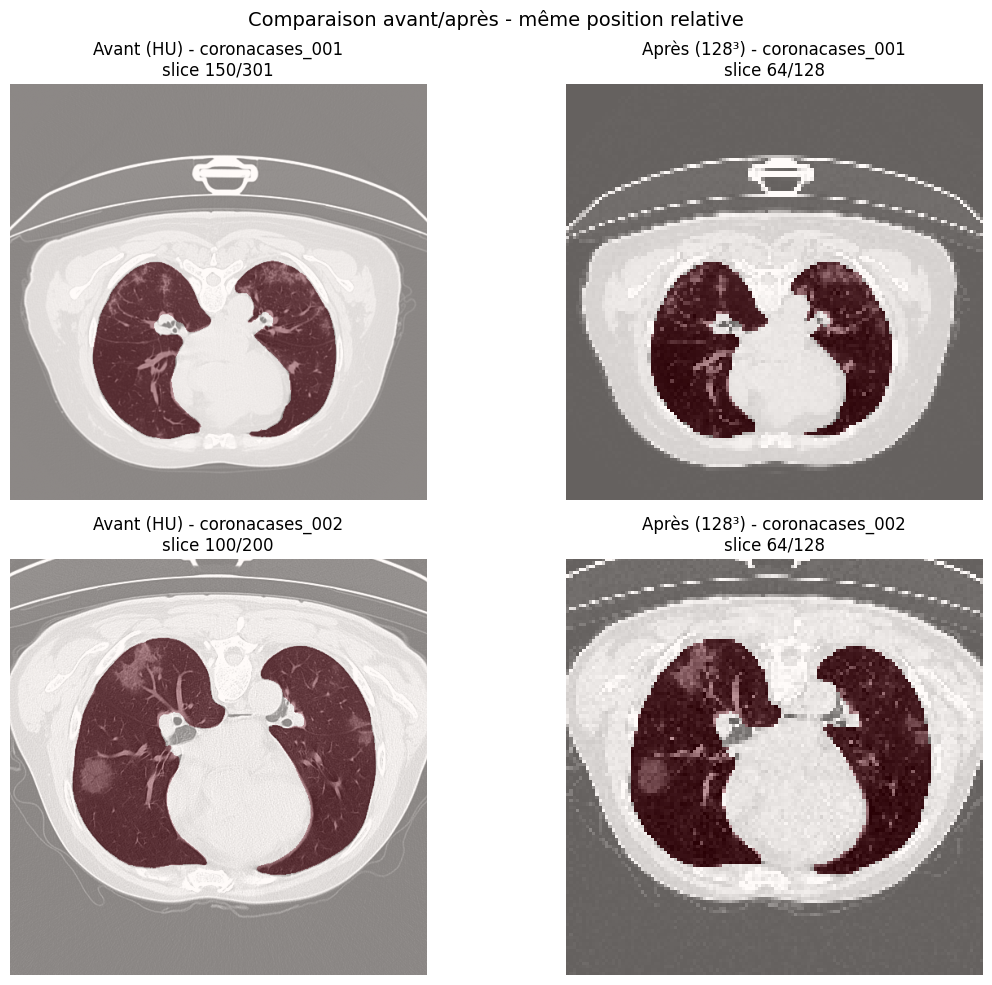

In [ ]:
# ============================================================
# Visualisation : comparaison slice à slice (même position relative)
# - Avant : slice centrale du volume original (après clipping+norm pour affichage)
# - Après : slice correspondante dans le volume prétraité (128³)
# Aucune transformation supplémentaire sur l'image prétraite.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import h5py
from huggingface_hub import hf_hub_download

# Choisir deux cas
case1 = paired_stems[0]
case2 = paired_stems[1] if len(paired_stems) > 1 else paired_stems[0]

def load_original(stem):
    ct_path = hf_hub_download(repo_id=REPO_RAW, filename=ct_by_stem[stem],
                              repo_type="dataset", token=HF_TOKEN)
    mask_path = hf_hub_download(repo_id=REPO_RAW, filename=mask_by_stem[stem],
                                repo_type="dataset", token=HF_TOKEN)
    ct = load_volume(ct_path)          # HU
    mask = load_volume(mask_path)      # labels 1,2,3
    return ct, mask

def load_preprocessed(stem):
    h5_path = hf_hub_download(repo_id=REPO_H5_OUT, filename=f"{stem}.h5",
                              repo_type="dataset", token=HF_TOKEN)
    with h5py.File(h5_path, "r") as f:
        ct = f["image"][:]    # (128,128,128) normalisé [0,1]
        mask = f["mask"][:]   # binaire
    return ct, mask

# Fenêtre d'affichage CT original (HU) : fenêtre pulmonaire
WINDOW_MIN, WINDOW_MAX = -1400, 200

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Comparaison avant/après - même position relative", fontsize=14)

for i, stem in enumerate([case1, case2]):
    # ---- Original ----
    ct_orig, mask_orig = load_original(stem)
    mask_bin = (mask_orig == 1) | (mask_orig == 2)
    z_orig = ct_orig.shape[0] // 2   # slice centrale (position 50%)
    slice_ct_orig = ct_orig[z_orig]
    slice_mask_orig = mask_bin[z_orig]

    # ---- Prétraité (128³) ----
    ct_pp, mask_pp = load_preprocessed(stem)
    # Calcul de l'indice correspondant à la même proportion (z_orig / total_orig)
    ratio = z_orig / ct_orig.shape[0]            # entre 0 et 1
    z_pp = int(round(ratio * ct_pp.shape[0]))    # slice dans le 128³
    z_pp = min(max(z_pp, 0), ct_pp.shape[0] - 1) # sécurité
    slice_ct_pp = ct_pp[z_pp]          # (128,128)
    slice_mask_pp = mask_pp[z_pp]

    # Affichage original (avec fenêtre HU)
    axes[i, 0].imshow(slice_ct_orig, cmap='gray', vmin=WINDOW_MIN, vmax=WINDOW_MAX)
    axes[i, 0].imshow(slice_mask_orig, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
    axes[i, 0].set_title(f"Avant (HU) - {stem}\nslice {z_orig}/{ct_orig.shape[0]}")
    axes[i, 0].axis('off')

    # Affichage prétraité (taille réelle 128x128)
    axes[i, 1].imshow(slice_ct_pp, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].imshow(slice_mask_pp, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
    axes[i, 1].set_title(f"Après (128³) - {stem}\nslice {z_pp}/{ct_pp.shape[0]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

Parcours de tous les cas (CT bruts)...


Chargement des volumes:   0%|          | 0/20 [00:00<?, ?it/s]

images/coronacases_003.nii.gz:   0%|          | 0.00/67.3M [00:00<?, ?B/s]

images/coronacases_004.nii.gz:   0%|          | 0.00/88.9M [00:00<?, ?B/s]

images/coronacases_005.nii.gz:   0%|          | 0.00/96.5M [00:00<?, ?B/s]

...

images/radiopaedia_36_86526_0.nii.gz:   0%|          | 0.00/8.33M [00:00<?, ?B/s]

images/radiopaedia_40_86625_0.nii.gz:   0%|          | 0.00/28.3M [00:00<?, ?B/s]

images/radiopaedia_4_85506_1.nii.gz:   0%|          | 0.00/10.1M [00:00<?, ?B/s]

images/radiopaedia_7_85703_0.nii.gz:   0%|          | 0.00/12.2M [00:00<?, ?B/s]


Statistiques sur 20 cas :
  - Nombre de slices MIN : 39
  - Nombre de slices MAX : 418
  - Moyenne              : 176.0
  - Médiane              : 200.0


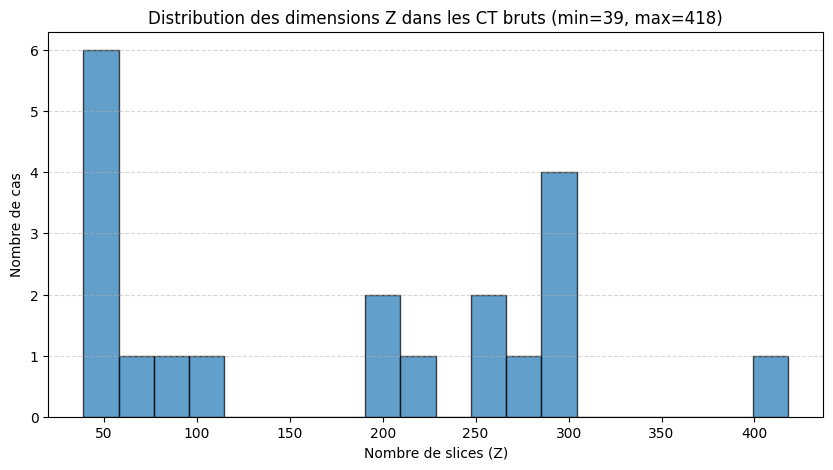

In [ ]:
# ============================================================
# Analyse des dimensions Z (nombre de slices) des CT bruts
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from huggingface_hub import hf_hub_download

z_sizes = []  # liste des nombres de slices (dimension Z)

print("Parcours de tous les cas (CT bruts)...")
for stem in tqdm(paired_stems, desc="Chargement des volumes"):
    # Récupérer le chemin HF du CT
    ct_hf_path = ct_by_stem[stem]

    # Télécharger le fichier NIfTI (local temporaire)
    ct_local = hf_hub_download(
        repo_id=REPO_RAW,
        filename=ct_hf_path,
        repo_type="dataset",
        token=HF_TOKEN
    )

    # Charger le volume (HU bruts)
    ct_vol = load_volume(ct_local)

    # Enregistrer la taille Z
    z_sizes.append(ct_vol.shape[0])

# Calcul des statistiques
z_min = np.min(z_sizes)
z_max = np.max(z_sizes)
z_mean = np.mean(z_sizes)
z_median = np.median(z_sizes)

print(f"\nStatistiques sur {len(z_sizes)} cas :")
print(f"  - Nombre de slices MIN : {z_min}")
print(f"  - Nombre de slices MAX : {z_max}")
print(f"  - Moyenne              : {z_mean:.1f}")
print(f"  - Médiane              : {z_median:.1f}")

# Affichage d'un histogramme
plt.figure(figsize=(10, 5))
plt.hist(z_sizes, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Nombre de slices (Z)")
plt.ylabel("Nombre de cas")
plt.title(f"Distribution des dimensions Z dans les CT bruts (min={z_min}, max={z_max})")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

stp azreeeeb
stppp
